In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
from datetime import datetime
print(datetime.today().strftime('%A'))

Friday


In [84]:
# Q1 Display the day for Sptember 11, 1952
from datetime import datetime
septEleven_1952 = datetime(1952, 9, 11)
print(septEleven_1952.strftime('%A'))

Thursday


In [85]:
# Q2 create dates starting from October 15, 2008 with 85 periods with day frequency
# What date is second to the last?
date_range = pd.date_range(start='2008-10-15', periods=85, freq='D')
print("Second to the last date:", date_range[-2])


Second to the last date: 2009-01-06 00:00:00


In [86]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cxp_crypto.csv', parse_dates=['Date'], index_col='Date')


In [87]:
df

,Close,Volume
Date,,
2015-01-02,36.926601,2.725885e+06
2015-01-03,37.340510,2.715483e+06
2015-01-04,37.799113,2.232065e+06
2015-01-05,36.941454,2.492695e+06
2015-01-06,36.962395,3.125070e+06
...,...,...
2018-12-27,69.272315,6.188229e+07
2018-12-28,69.320954,6.273084e+07
2018-12-29,68.915318,6.299823e+07


In [88]:
print(df.head())

                Close       Volume
Date                              
2015-01-02  36.926601  2725884.731
2015-01-03  37.340510  2715483.462
2015-01-04  37.799113  2232065.193
2015-01-05  36.941454  2492694.925
2015-01-06  36.962395  3125069.656


In [89]:
# Display column names
print(df.columns)

Index(['Close', 'Volume'], dtype='object')


In [90]:
# Resampling time series to different frequencies
# Q3 If you resample the "Close" column to weekly mean frequency, what is the value of 2016-05-01?
weekly_mean = df['Close'].resample('W').mean()
value_2016_05_01 = weekly_mean.loc['2016-05-01']
print(value_2016_05_01)

47.194214214285715


In [91]:
# Q4 If you resample the "close" to quarter end median frequency, what is the value of 2017-12-31?
quarterly_median = df['Close'].resample('Q').median()
value_2017_12_31 = quarterly_median.loc['2017-12-31']
print(value_2017_12_31)

59.62065219


<ipython-input-91-3264508d076c>:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_median = df['Close'].resample('Q').median()


In [92]:
# Q5 If you resample the 'Volume' column to semi-month end mean frequency, what is the median value of the last five dates?
semi_month_mean = df['Volume'].resample('SM').mean()

last_five_median = semi_month_mean.tail(5).median()
print(last_five_median)

61114715.585999995


<ipython-input-92-b221d85d41a2>:2: FutureWarning: 'SM' is deprecated and will be removed in a future version, please use 'SME' instead.
  semi_month_mean = df['Volume'].resample('SM').mean()


<ipython-input-93-ee4adadbb983>:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df['Close'].resample('Q').max().plot.bar(figsize=(16,6),title=title,color=['#1f77b4']);


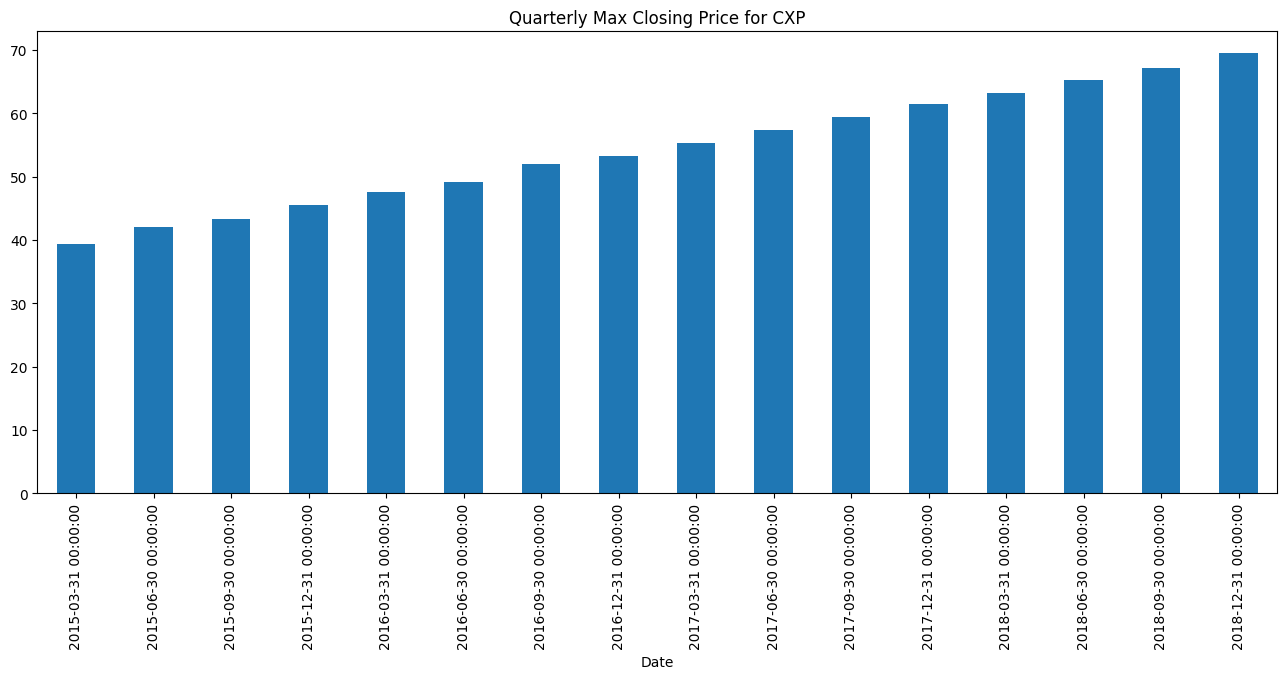

In [93]:
#Q6
title = 'Quarterly Max Closing Price for CXP'
df['Close'].resample('Q').max().plot.bar(figsize=(16,6),title=title,color=['#1f77b4']);

In [94]:
# Q7 If I shift forward the CXP data by a value of 17, what is the new value of 'Close' price for 2015-02-26?
df.shift(17).loc['2015-02-26', 'Close']


38.1813435

In [95]:
# Q8 If I shift backwards the CXP data by a value of 28, what is the new value of 'Close' price for 2018-08-31?
df.shift(-28).loc['2018-08-31', 'Close']

66.91537483

In [96]:
# Q9 Using moving average (rolling) with 14 days window, find the closing price at 2015-04-09
df.rolling(window=14).mean().loc['2015-04-09', 'Close']

38.83933309714286

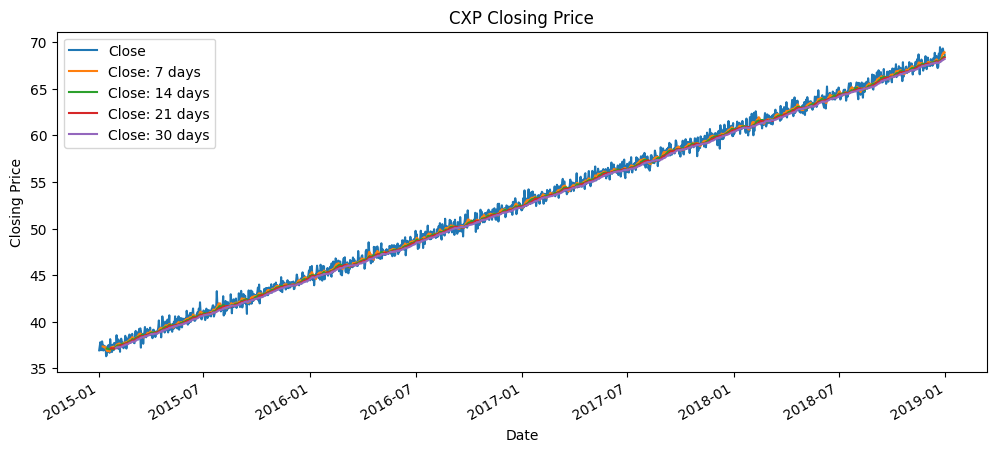

In [97]:
# Q10 Create the graph below with different rolling windows of 7, 14, 21, 30

df['Close: 7 days'] = df['Close'].rolling(window=7).mean()
df['Close: 14 days'] = df['Close'].rolling(window=14).mean()
df['Close: 21 days'] = df['Close'].rolling(window=21).mean()
df['Close: 30 days'] = df['Close'].rolling(window=30).mean()

df[['Close', 'Close: 7 days', 'Close: 14 days',
    'Close: 21 days', 'Close: 30 days']].plot(figsize=(12,5))

plt.title('CXP Closing Price')
plt.ylabel('Closing Price')
plt.show()

In [98]:
# Q11 Based on the graph above, what is your take on increasing and decreasing number of windows for rolling or moving average